In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import math

class GaussianEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=128, min_logvar=-8.0, max_logvar=4.0):
        super().__init__()

        self.min_logvar = min_logvar
        self.max_logvar = max_logvar

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )

        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = self.net(x)

        mu = self.mu(h)

        # bounded encoder variance
        logvar = self.logvar(h)
        logvar = torch.clamp(logvar, self.min_logvar, self.max_logvar)

        return mu, logvar


class LangevinDecoder(nn.Module):
    def __init__(self, latent_dim, output_dim, hidden_dim=128, min_logvar=-8.0, max_logvar=4.0, constant_diffusion=False):
        super().__init__()

        self.min_logvar = min_logvar
        self.max_logvar = max_logvar
        self.constant_diffusion = constant_diffusion

        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
        )

        self.drift = nn.Linear(hidden_dim, output_dim)
        if constant_diffusion:
            self.log_diffusion = nn.Parameter(torch.tensor(0.0))
        else:
            self.log_diffusion = nn.Linear(hidden_dim, output_dim)

        # Start close to D ~ exp(-2) ~ 0.135
        nn.init.zeros_(self.drift.weight)
        nn.init.zeros_(self.drift.bias)

        
        if not constant_diffusion:
            nn.init.zeros_(self.log_diffusion.weight)
            nn.init.constant_(self.log_diffusion.bias, 0.0)

    def forward(self, z):
        h = self.net(z)

        if self.constant_diffusion:
            drift = self.drift(h)
            log_diffusion = torch.clamp(
                self.log_diffusion,
                self.min_logvar,
                self.max_logvar,
            ).expand_as(drift)
        else:
            drift = self.drift(h)
            log_diffusion = self.log_diffusion(h)
            log_diffusion = torch.clamp(
                log_diffusion,
                self.min_logvar,
                self.max_logvar,
            )

        return drift, log_diffusion

In [ ]:
def vib_loss(
    encoder,
    decoder,
    beta,
    x,
    delta_x,
    tau,
):
    # tau: [B] or [B, 1]
    if tau.ndim == 1:
        tau = tau.unsqueeze(-1)

    if not torch.isfinite(tau).all():
        raise ValueError("tau contains NaN/Inf")

    if (tau <= 0).any():
        raise ValueError("all tau values must be > 0")

    # -----------------------
    # Encoder q(z | x)
    # -----------------------

    mu_z, logvar_z = encoder(x)

    eps = torch.randn_like(mu_z)
    z = mu_z + torch.exp(0.5 * logvar_z) * eps

    kl = 0.5 * (
        torch.exp(logvar_z)
        + mu_z.square()
        - 1.0
        - logvar_z
    ).sum(dim=-1).mean()

    # -----------------------
    # Decoder
    # -----------------------

    drift_z, log_D_z = decoder(z)

    # E[Delta x | z, tau] = tau * b(z)
    mu_delta = tau * drift_z

    # Var[Delta x | z, tau] = 2 tau D(z)
    logvar_delta = torch.log(2.0 * tau) + log_D_z

    residual = delta_x - mu_delta

    nll = 0.5 * (
        logvar_delta
        + residual.square() * torch.exp(-logvar_delta)
    ).sum(dim=-1).mean()

    loss = nll + beta * kl

    return loss, nll, kl

In [ ]:
folder = Path("data/SwitchingTrap/280nm/")
files = list(folder.glob("*.txt"))
file = files[0]
data = np.loadtxt(file)
t = data[:, 0]
x = data[:, [1,2]]
x_mean = np.mean(x, axis=0)
x_std = np.std(x, axis=0)
x = (x - x_mean) / x_std

In [ ]:
D_x = 1.0
D_y = 1.0
gamma_x = 1.0
gamma_y = 1.0
omega = 0.5
D = np.array([[D_x, 0], [0, D_y]])
A = np.array([[gamma_x, -omega], [omega, gamma_y]])
num_steps = 100000
dt = 0.01
trace = np.zeros((num_steps, 2))
for i in range(1, num_steps):
    noise = np.random.multivariate_normal(mean=np.zeros(2), cov=2*D*dt)
    trace[i] = trace[i-1] + noise - dt * A @ trace[i-1]

In [ ]:
x = trace

t = np.arange(num_steps) * dt

In [157]:
encoder = GaussianEncoder(input_dim=2, latent_dim=16, hidden_dim=8).to(device)
decoder = LangevinDecoder(latent_dim=16, output_dim=2, hidden_dim=8, constant_diffusion=True).to(device)

In [158]:
max_gap = 10
num_epochs = 20
num_timepoints_per_batch = 100
num_batches = 1000
learning_rate = 1e-4
beta = 1e-5
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=learning_rate)
for epoch in range(num_epochs):
    pbar = tqdm(range(num_batches), desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch in pbar:
        optimizer.zero_grad()
        indices = np.random.choice(len(t) - max_gap, num_timepoints_per_batch, replace=False)
        next_indices = indices + np.random.randint(1, max_gap + 1, size=num_timepoints_per_batch)
        x_batch = torch.tensor(x[indices], dtype=torch.float32).to(device)
        x_next_batch = torch.tensor(x[next_indices], dtype=torch.float32).to(device)
        delta_x_batch = x_next_batch - x_batch
        tau = torch.tensor(t[next_indices] - t[indices], dtype=torch.float32).to(device)
        loss, nll_decoder, kl_encoder = vib_loss(encoder, decoder, beta=beta, x=x_batch, delta_x=delta_x_batch, tau=tau)
        loss.backward()
        optimizer.step()
        pbar.set_postfix({"loss": loss.item(), "nll_decoder": nll_decoder.item(), "kl_encoder": kl_encoder.item()})

Epoch 1/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 3/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5/20:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 16/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 17/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 18/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 19/20:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 20/20:   0%|          | 0/1000 [00:00<?, ?it/s]

In [159]:
@torch.no_grad()
def integrate_trajectory(
    encoder,
    decoder,
    x0,
    taus,
    sample_latent=True,
    sample_dynamics=True,
):
    """
    x0:   [B, x_dim] or [x_dim]
    taus: [T] sequence of time steps

    returns:
        trajectory: [T+1, B, x_dim]
    """

    if x0.ndim == 1:
        x0 = x0.unsqueeze(0)

    x = x0.clone()
    trajectory = [x.clone()]

    for tau in taus:
        tau = torch.as_tensor(
            tau,
            dtype=x.dtype,
            device=x.device,
        )

        # q(z | x)
        mu_z, logvar_z = encoder(x)

        if sample_latent:
            std_z = torch.exp(0.5 * logvar_z)
            z = mu_z + std_z * torch.randn_like(std_z)
        else:
            z = mu_z

        # learned drift and diffusion
        drift, log_D = decoder(z)
        D = torch.exp(log_D)

        # Euler-Maruyama step
        mean_increment = tau * drift

        if sample_dynamics:
            noise = torch.randn_like(x)
            stochastic_increment = torch.sqrt(
                2.0 * tau * D
            ) * noise
        else:
            stochastic_increment = 0.0

        x = x + mean_increment + stochastic_increment

        trajectory.append(x.clone())

    return torch.stack(trajectory)

In [160]:
x0 = torch.tensor([0.0,0.0], device=device)

taus = torch.full(
    (1000,),
    0.1,
    device=device,
)

traj = integrate_trajectory(
    encoder,
    decoder,
    x0,
    taus,
).cpu()

In [161]:
@torch.no_grad()
def estimate_drift_diffusion_stats(
    encoder,
    decoder,
    x,
    n_samples=500,
):
    if x.ndim == 1:
        x = x.unsqueeze(0)

    mu_z, logvar_z = encoder(x)
    std_z = torch.exp(0.5 * logvar_z)

    z = (
        mu_z.unsqueeze(0)
        + std_z.unsqueeze(0)
        * torch.randn(
            n_samples,
            *mu_z.shape,
            device=x.device,
        )
    )

    S, B, latent_dim = z.shape

    drift, log_D = decoder(
        z.reshape(S * B, latent_dim)
    )

    D = torch.exp(log_D)

    x_dim = drift.shape[-1]

    drift = drift.reshape(S, B, x_dim)
    D = D.reshape(S, B, x_dim)

    return {
        "b": drift.mean(0),
        "b_std": drift.std(0),
        "D": D.mean(0),
        "D_std": D.std(0),
    }

In [162]:
x_grid = torch.meshgrid(
    torch.linspace(-1, 1, 25, device=device),
    torch.linspace(-1, 1, 25, device=device),
)
x_grid = torch.stack(x_grid, dim=-1).reshape(-1, 2)

stats = estimate_drift_diffusion_stats(
    encoder,
    decoder,
    x_grid,
    n_samples=500,
)

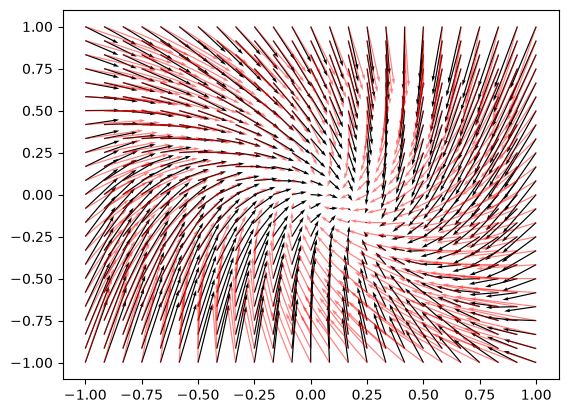

In [163]:
b = stats["b"].cpu()
b_std = stats["b_std"].cpu()
D = stats["D"].cpu()
D_std = stats["D_std"].cpu()
true_b = - A @ x_grid.cpu().numpy().T
A_inferred = - b.cpu().numpy().T @ np.linalg.pinv(x_grid.cpu().numpy().T)
plt.quiver(
    x_grid.cpu()[:, 0],
    x_grid.cpu()[:, 1],
    b[:, 0],
    b[:, 1],
    color="black",
    alpha=1.0,
    scale=10.0,
)
plt.quiver(
    x_grid.cpu()[:, 0],
    x_grid.cpu()[:, 1],
    true_b[0, :],
    true_b[1, :],
    color="red",
    alpha=0.5,
    scale=10.0,
)

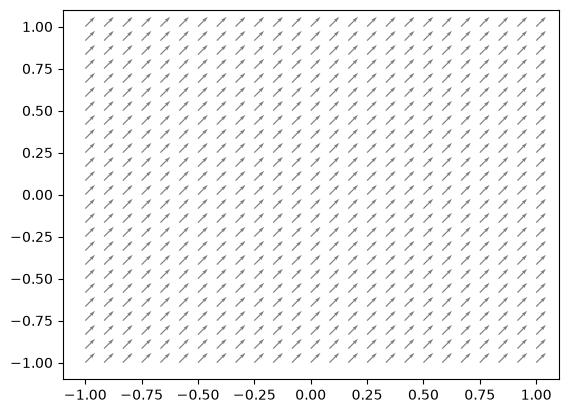

In [164]:
D = stats["D"].cpu()
D_std = stats["D_std"].cpu()
plt.quiver(
    x_grid.cpu()[:, 0],
    x_grid.cpu()[:, 1],
    D[:, 0].sqrt(),
    D[:, 1].sqrt(),
    color="black",
    alpha=0.5,
    scale=50.0,
)

In [156]:
A_inferred, D.mean(0)

(array([[ 0.93539476, -0.29299366],
        [ 0.27158594,  0.951445  ]], dtype=float32),
 tensor([0.6740, 0.6740]))